# Reading the data (with minimal preprocessing)...

In [2]:
import pandas as pd
import numpy as np
from cmdstanpy import CmdStanModel
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from sklearn.model_selection import train_test_split


C:\Users\ronin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_full = pd.read_csv("data/Speed_Dating_Data.csv", encoding="latin1")
df_full.head()


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


The attributes I choose are attractiveness, fun, and shared interests. 
Since participants only talk for 4 minutes, it would make sense that a participant would mainly judge if he/she wants to see the other person based on "easily observable" traits, such as attractiveness and fun / "mutual vibe". 
Additionally, talking about commonality would most likely be a go-to topic since it's such a short conversation. 

In [4]:
# now selecting only the attr we chosen...
df = df_full[["dec", "attr", "fun", "shar"]].copy()
df.head()

,dec,attr,fun,shar
0,1,6.0,7.0,5.0
1,1,7.0,8.0,6.0
2,1,5.0,8.0,7.0
3,1,7.0,7.0,8.0
4,1,5.0,7.0,6.0


In [5]:
# looking at shape and if there's missing vals...
print(df.shape)
print(df.isna().sum())

(8378, 4)
dec        0
attr     202
fun      350
shar    1067
dtype: int64


In [6]:
# dropping data pts (rows) with missing vals...
df = df.dropna().copy()

print(df.shape)
df.head()

(7256, 4)


,dec,attr,fun,shar
0,1,6.0,7.0,5.0
1,1,7.0,8.0,6.0
2,1,5.0,8.0,7.0
3,1,7.0,7.0,8.0
4,1,5.0,7.0,6.0


In [7]:
# for binary classification val, we observe that there is no class imbalance... 
print(df["dec"].value_counts())
print(df["dec"].unique())

dec
0    4112
1    3144
Name: count, dtype: int64
[1 0]


# Splitting the data...

we only need train test split, no validation.

thus, we go with 80 20 train-test split

In [8]:
# fixed random seed for reproducibility...
np.random.seed(42)
idx = np.random.permutation(len(df))

split = int(0.8 * len(df))
train_idx = idx[:split]
test_idx = idx[split:]

X_train = df.iloc[train_idx].copy()
X_test = df.iloc[test_idx].copy()

print(X_train.shape)
print(X_test.shape)


(5804, 4)
(1452, 4)


In [9]:
X_train.head()

,dec,attr,fun,shar
3428,0,4.0,3.0,5.0
1949,1,9.0,7.0,7.0
4534,0,7.0,7.0,4.0
7340,0,2.0,10.0,4.0
7802,1,10.0,10.0,5.0


# Mean centering and scaling the data...

since we're not allowed to look at the testset in advance, we will meancenter and scale the testset wrt to the train set, since it comes from the same dataset

In [ ]:
y_train = X_train["dec"].copy()
y_test = X_test["dec"].copy()

# dont standardise the target var...
attrs = ["attr", "fun", "shar"]

# compute mean and stdev of training set only...
train_mu = X_train[attrs].mean()
train_sigma = X_train[attrs].std()

X_train_standardised = (X_train[attrs] - train_mu) / train_sigma
X_test_standardised = (X_test[attrs] - train_mu) / train_sigma


# sanity checking...
print(X_train_standardised.head())
print()

# 10^-17 is effectively 0 due to floating point error...
print(X_train_standardised.mean())
print()

# indeed the stdev is 1 for each column... good.
print(X_train_standardised.std())
print()

print(y_train.head())

          attr       fun      shar
3428 -1.113032 -1.712469 -0.215278
1949  1.439657  0.308098  0.710774
4534  0.418581  0.308098 -0.678304
7340 -2.134108  1.823523 -0.678304
7802  1.950195  1.823523 -0.215278

attr   -2.111796e-17
fun     1.392561e-16
shar   -1.273199e-16
dtype: float64

attr    1.0
fun     1.0
shar    1.0
dtype: float64

3428    0
1949    1
4534    0
7340    0
7802    1
Name: dec, dtype: int64


# Stan-based Bayesian regression

Our decision variable is binary, so hence, the appropiate likelihood is Bernoulli.
That is, for sample $n$, we have that $y_n \sim \mathrm{Bernoulli}(p_n)$.


Particularly, our Bayesian linear regression probability for sample $n$ is formulated as follows:
$$
\mathrm{logit}(p_n) = \beta_0 
+ \beta_{\mathrm{attr}}x_{\mathrm{attr},n} 
+ \beta_{\mathrm{fun}}x_{\mathrm{fun},n} 
+ \beta_{\mathrm{shar}}x_{\mathrm{shar},n},
$$
where $\beta_0, \beta_{\mathrm{attr}}, \beta_{\mathrm{fun}}, \beta_{\mathrm{shar}} \sim \mathcal{N}(0, 2.5)$.

Then, we obtain $p_n$ itself through the sigmoid function, which is 
$$
\frac{1}{1 + \exp^{- (\beta_0 
+ \beta_{\mathrm{attr}}x_{\mathrm{attr},n} 
+ \beta_{\mathrm{fun}}x_{\mathrm{fun},n} 
+ \beta_{\mathrm{shar}}x_{\mathrm{shar},n})}}
.
$$

In [11]:
data_dict = {
    "N": len(y_train),
    "y": y_train.to_numpy().astype(int),
    "X": X_train_standardised[["attr", "fun", "shar"]].to_numpy()
}

model = CmdStanModel(stan_file="models/q3.stan")
fit = model.sample(data=data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

22:48:16 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]


chain 1:   3%|▎         | 100/3500 [00:00<00:19, 178.17it/s, (Warmup)]


chain 1:   6%|▌         | 200/3500 [00:01<00:18, 180.68it/s, (Warmup)]


chain 1:   9%|▊         | 300/3500 [00:01<00:15, 203.11it/s, (Warmup)]


chain 1:  11%|█▏        | 400/3500 [00:01<00:13, 227.10it/s, (Warmup)]


chain 1:  14%|█▍        | 500/3500 [00:02<00:12, 236.98it/s, (Warmup)]




chain 1:  17%|█▋        | 600/3500 [00:02<00:11, 246.81it/s, (Warmup)]


chain 1:  20%|██        | 700/3500 [00:02<00:10, 262.31it/s, (Warmup)]


chain 1:  23%|██▎       | 800/3500 [00:03<00:09, 278.60it/s, (Warmup)]


chain 1:  26%|██▌       | 900/3500 [00:03<00:08, 289.71it/s, (Warmup)]




chain 1:  29%|██▊       | 1000/3500 [00:03<00:08, 283.27it/s, (Sampling)]




chain 1:  34%|███▍      | 1200/3500 [00:04<00:08, 279.74it/s, (Sampling)]


chain 1:  37%|███▋      | 1300/3500 [00:05<00:08, 274.13it/s, (Sampl


22:48:30 - cmdstanpy - INFO - CmdStan done processing.


In [12]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-2995.630000,0.019552,1.390730,1.222110,-2998.330000,-2995.320000,-2994.000000,5104.47,7219.64,136.185,0.999917
beta_0,-0.421049,0.000321,0.032179,0.032330,-0.473343,-0.421058,-0.368412,10077.80,8063.98,268.869,1.000210
beta[1],1.004900,0.000474,0.045319,0.045713,0.930623,1.005260,1.079630,9134.35,7879.59,243.700,1.000020
beta[2],0.371229,0.000508,0.046225,0.046382,0.294362,0.371254,0.448267,8395.46,6995.10,223.986,0.999832
beta[3],0.488783,0.000483,0.041807,0.041341,0.419778,0.489152,0.557280,7560.14,7573.59,201.701,1.000130


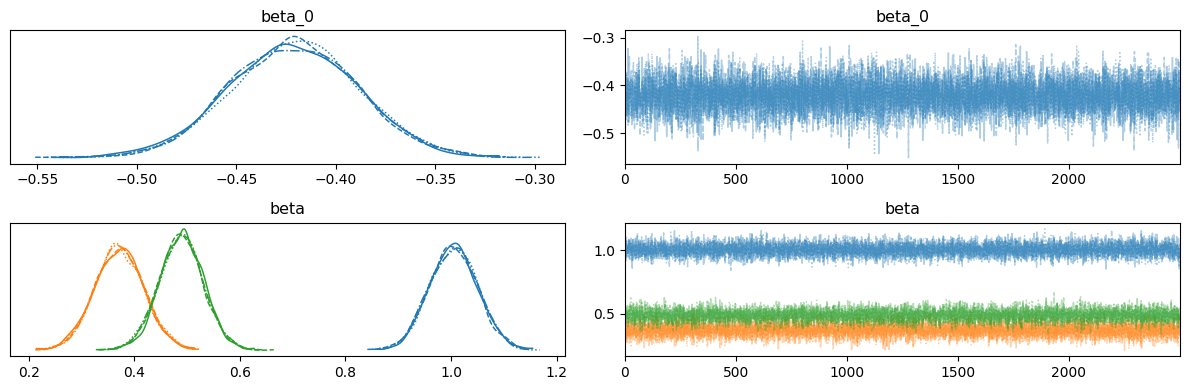

In [13]:
# Traceplots and marginals - visual convergence checks
axarr = az.plot_trace(fit)
plt.tight_layout()

# Use of train test split...?

For this homework pdf for this question, it was not very clear what I need to use the train test split for... 

I assume I must use it somehow, and the best idea I can think of it is to use my recovered betas to test the accuracy of my Bayesian regression model as described above.

As shown in the math in the previous section, we use the recovered $\beta_i, i=0,\cdots,3$ to predict $y$ on the test set.

In [14]:
# obtaining the beta means...
beta_means = fit.summary().loc[['beta[1]', 'beta[2]', 'beta[3]'], 'Mean'].values
beta_0_mean = fit.summary().loc['beta_0', 'Mean']

# using the inverse logit (sigmoid) function to get p_n...
from scipy.special import expit 
logits = beta_0_mean + X_test_standardised @ beta_means
test_probs = expit(logits)

# converting probabilities to 0 or 1 predictions (threshold at 0.5)...
predictions = (test_probs > 0.5).astype(int)

# comparing to the test set labels...
accuracy = (predictions == y_test).mean()
print(f"Test Set Accuracy: {accuracy:.2%}")

Test Set Accuracy: 75.28%
